# Lab 11 - Perceptrons

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1

In [2]:
# Perceptron Function
def perceptron(inputs, weights, bias):
  weighted_sum = sum(x * w for x, w in zip(inputs, weights)) + bias
  print(f"Weighted sum: {weighted_sum}")
  return 1 if weighted_sum >= 50 else 0

# Inputs and Parameters
inputs = [4, 3, 0, 80] # Hours studied and slept
weights = [0.6, 0.4, 0.9, 0.5]
bias  = -0.9

# Prediction
output = perceptron(inputs, weights, bias)
print(f"Prediction (Pass = 1, Fail = 0): {output}")

Weighted sum: 42.7
Prediction (Pass = 1, Fail = 0): 0


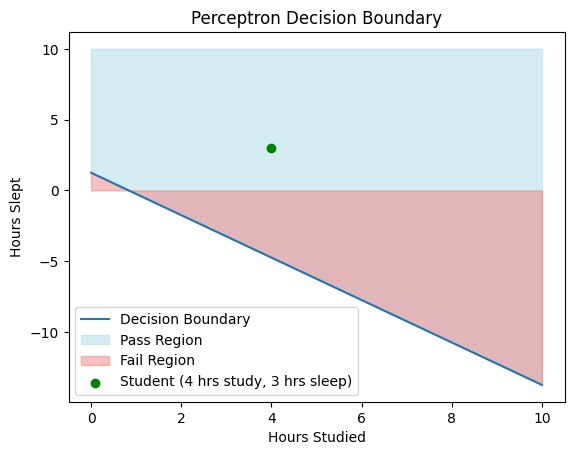

In [3]:
# Parameters
weights = np.array([0.6, 0.4])
bias = -0.5

# Decision boundary: w1*x1 + w2*x2 + b = 0
x1 = np.linspace(0, 10, 100)
x2 = -(weights[0] * x1 + bias) / weights[1] # Solve for x2

plt.plot(x1, x2, label="Decision Boundary")
plt.fill_between(x1, x2, 10, color="lightblue", alpha=0.5, label="Pass Region")
plt.fill_between(x1, x2, 0, color="lightcoral", alpha=0.5, label="Fail Region")
plt.scatter(4, 3, color="green", label="Student (4 hrs study, 3 hrs sleep)")
plt.xlabel("Hours Studied")
plt.ylabel("Hours Slept")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.show()

## Task 2

### General code

In [2]:
def bin_desicion(x):
  return 1 if x >= 0 else 0

In [3]:
def train_perceptron(X, y, learning_rate=0.01, epochs=20):
    # Initialize weights and bias
    weights = np.zeros(X.shape[1])
    bias = 0

    # Loop through the dataset multiple times
    for _ in range(epochs):
        for i in range(len(X)):
            linear_output = np.dot(X[i], weights) + bias
            y_pred = bin_desicion(linear_output)

            # Calculate error
            error = y[i] - y_pred

            # Update weights and bias
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

    return weights, bias

In [4]:
def predict(X, weights, bias):
    predictions = []
    for x in X:
        linear_output = np.dot(x, weights) + bias
        predictions.append(bin_desicion(linear_output))
    return predictions

### Loan Approval Prediction

In [5]:
# Inputs: [Monthly Income, Credit Score]
X = np.array([
    [3000, 650],
    [1500, 500],
    [4000, 700],
    [2000, 550]
])

# Output: 1 = Approved, 0 = Rejected
y = np.array([1, 0, 1, 0])

In [6]:
weights, bias = train_perceptron(X, y, learning_rate=0.01, epochs=20)

print("Trained Weights:", weights)
print("Trained Bias:", bias)

Trained Weights: [  5. -19.]
Trained Bias: -0.05


In [7]:
LoanLabel = {1: "Loan Approved Class", 0: "Loan Rejected"}

In [8]:
test_data = np.array([
    [2500, 600],
    [4500, 750]
])

predictions = predict(test_data, weights, bias)

for i in range(len(test_data)):
    print(f"testcase {i+1} → {LoanLabel[predictions[i]]}")

testcase 1 → Loan Approved Class
testcase 2 → Loan Approved Class


### Email Spam Detection

In [9]:
# Features: [Number of Suspicious Keywords, Number of Links]
X = np.array([
    [1, 0],   # Not spam
    [3, 1],   # Spam
    [0, 0],   # Not spam
    [4, 2],   # Spam
    [2, 0],   # Not spam
    [5, 3]    # Spam
])

# Labels: 1 = Spam, 0 = Not Spam
y = np.array([0, 1, 0, 1, 0, 1])

In [10]:
weights, bias = train_perceptron(X, y, learning_rate=0.1, epochs=20)

print("Trained Weights:", weights)
print("Trained Bias:", bias)

Trained Weights: [0.1 0.5]
Trained Bias: -0.4


In [11]:
labels = {1: "Spam", 0: "Not Spam"}

In [12]:
test_emails = np.array([
    [1, 1],   # Few keywords, one link
    [4, 2],   # Many keywords, many links
    [0, 0]    # Clean email
])

predictions = predict(test_emails, weights, bias)
for i in range(len(test_emails)):
    print(f"Email {i+1}: {labels[predictions[i]]}")
print("Predictions:", predictions)

Email 1: Spam
Email 2: Spam
Email 3: Not Spam
Predictions: [1, 1, 0]


### Weather-Based Decision (Play or Not Play)

In [13]:
# Features: [Temperature, Raining]
X = np.array([
    [7, 1],   # Not Play
    [15, 0],  # Play
    [32, 0],  # Not Play
    [25, 1],  # Play
    [10, 0],  # Play
    [3, 0],   # Not Play
    [17, 1],  # Play
    [30, 0],  # Not Play
    [6, 0]    # Not Play
])

# Labels: 1 = Play, 0 = Not Play
y = np.array([0, 1, 0, 1, 1, 0, 1, 0, 0])

In [14]:
weights, bias = train_perceptron(X, y, learning_rate=0.1, epochs=20)

print("Trained Weights:", weights)
print("Trained Bias:", bias)

Trained Weights: [-2.9  1.9]
Trained Bias: -0.1


In [15]:
labelsWeather = {1: "Play", 0: "Not Play"}

In [16]:
test_data = np.array([
    [24, 1],
    [4, 1]
])

predictions = predict(test_data, weights, bias)

for i in range(len(test_data)):
    print(f"testcase {i+1} → {labelsWeather[predictions[i]]}")
print("Predictions:", predictions)

testcase 1 → Not Play
testcase 2 → Not Play
Predictions: [0, 0]


### Employee Performance Classification

### Disease Risk Prediction (Basic)